In [1]:
# Transformers example -> Reverseing sequence of numbers


In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer

from sbi.analysis import pairplot
import numpy as np

jax.devices()

I0000 00:00:1699264467.049142  138543 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-11-06 10:54:33.181370: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [2]:
jax.devices("cpu")

[CpuDevice(id=0)]

In [3]:
jax.devices("gpu")

[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [4]:
ts = jnp.linspace(0, 3, 100)

def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey



In [5]:
num_timeponts = 48
time_start = 0
time_end = 10
ts_dense = jnp.linspace(time_start, time_end, 100)
def generate_data(key, n):

    key1, key2, key3, key4, key5, key6, key_t = jrandom.split(key, 7)

    theta1 = jax.nn.sigmoid(jrandom.normal(key1, (n,1)))*2 + 1.
    theta2 = jax.nn.sigmoid(jrandom.normal(key2, (n,1)))*2 + 1.
    theta3 = jax.nn.sigmoid(jrandom.normal(key3, (n,1)))*2 + 1.
    theta4 = jax.nn.sigmoid(jrandom.normal(key4, (n,1)))*2 + 1.
    
    # Random time points 
    ts = jrandom.uniform(key_t, (n , num_timeponts), minval=time_start, maxval=time_end)
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    predator = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, predator)
    prey = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, prey)

    predator = predator + jrandom.normal(key5, predator.shape) * 0.001
    prey = prey + jrandom.normal(key6, prey.shape) * 0.001

    node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
    node_metadata = jnp.concatenate([jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),ts, ts], axis=1)
    full_data = jnp.concatenate([theta1, theta2, theta3, theta4, predator, prey], axis=1).reshape((n, -1, 1))
    return full_data, node_ids, node_metadata


data, node_ids, node_metadata = generate_data(jrandom.PRNGKey(1
                                                              ), 2)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

print(T_max)

In [ ]:
time_evals = node_metadata[:, 4:4+num_timeponts]
predator_trace = data[:, 4:4+num_timeponts]
prey_trace = data[:, 4+num_timeponts:]

for i in range(1):
    plt.scatter(time_evals[i], predator_trace[i], c='C0', alpha=0.5)
    plt.scatter(time_evals[i], prey_trace[i], c='C1', alpha=0.5)
    plt.xlim(0, 10)

In [ ]:
key = jrandom.PRNGKey(0)

In [ ]:
from probjax.nn.helpers import SinusoidalEmbedding

In [ ]:

def model(t, x, node_ids, node_metadata, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions

    dim = 210
    _dim = dim // 3
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim, w_init=hk.initializers.RandomNormal(mean=3., stddev=0.01))
    embedding_metadata = SinusoidalEmbedding(_dim)
    embedding_time = SinusoidalEmbedding(_dim)
    

    # Positional embedding

    model = Transformer(num_heads=8, num_layers=8, attn_size=20, dropout_rate=0.0, widening_factor=4)

    # Embed values adn time
    value_embeddings = embedding_net(x)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape[:-1] + (_dim,))

    # Embed node ids and metadata
    id_embeddings = embedding_id_nets(node_ids)
    metadata_embeddings = embedding_metadata(node_metadata.reshape(-1,x.shape[1],1))
    metadata_embeddings = metadata_embeddings * ~jnp.isnan(metadata_embeddings)
    metadata_embeddings = jnp.broadcast_to(metadata_embeddings, value_embeddings.shape)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    node_emebding = id_embeddings

    # Condition embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(mean=-3.,stddev=0.1))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, x.shape[1],1)
    


    x_encoded = jnp.concatenate([value_embeddings, node_emebding, metadata_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding

    # Encode
    h = model(x_encoded, context=time_embeddings)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [ ]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, node_metadata, jnp.zeros_like(node_ids))

In [ ]:
params = jnp.load("transformer_based_inference_diffusion_lotka_volterra.npz", allow_pickle=True)["arr_0"].item()

In [ ]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids,node_metadata, jnp.zeros_like(node_ids))

In [ ]:
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [ ]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, key, batch_size= 64):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs, node_ids, node_metadata = generate_data(rng_data, batch_size) # n, T_max, 1

 
    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0]*T_max, [1,1,1,1] + [0]*(T_max-4),[0,0,0,0] + [1]*(T_max-4), jrandom.bernoulli(rng_permute_ids, 0.3, shape=(T_max,)).astype(int),jrandom.bernoulli(rng_permute_ids + 1, 0.7, shape=(T_max,)).astype(int)]), shape=(batch_size, ), axis=0)
    condition_mask = condition_mask[..., None]


    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-condition_mask) + batch_xs * condition_mask # Condition on the data

    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, node_ids,node_metadata, condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    # lam = beta(times) 
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times) + 1e-4
    # Loss

    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


# @jax.jit
# def update(params, rng, opt_state):
#     loss, grads = jax.value_and_grad(loss_fn)(params, rng)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return loss, params, opt_state

In [ ]:
from functools import partial

@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    grads = jax.lax.pmean(grads, axis_name='num_devices')
    loss = jax.lax.pmean(loss, axis_name='num_devices')
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [ ]:
optimizer = optax.adam(1e-4)
opt_state = optimizer.init(params)

In [ ]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [ ]:
key = jrandom.PRNGKey(0)
for j in range(25):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

18.462406
14.397457
10.16686
5.922864
4.3560853
3.7924867
3.2328825
2.8356893
2.6838157
2.6550086
2.3221233
2.124926
2.2280598
1.8842045
1.8949057
2.0065897
1.6706457
1.7100952
1.7110863
1.5312971
1.5583136
1.8667637
1.5267487
1.5513272
1.5816876


In [19]:
key = jrandom.PRNGKey(1)
for j in range(25):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

1.4337142
1.4451412
1.5324427
1.4677427
1.4277045
1.3724244
1.3620178
1.3567992
1.3672413
1.4067436
1.56681
1.2187148
1.3637805
1.4600736
1.4919157
1.2279388
1.3710622
1.3396803
1.3632782
1.2050704
1.1492383
1.1611471
1.3811443
1.2737657
1.3772755


In [18]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [19]:
jnp.savez("transformer_based_inference_diffusion_lotka_volterra.npz", params)

In [ ]:
from functools import partial

node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(jnp.linspace(time_start + 0.01, time_end , num_timeponts)) + list(jnp.linspace(time_start +0.01, time_end, num_timeponts))) # Time points
condition_mask = jnp.array([0]*T_max, dtype=int)
condition_value = jnp.array([0]*T_max)

def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask, node_metadata=node_metadata):
    #t = T - t
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,node_metadata, condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask[:len(node_ids)])
    return f

def diffusion_backward(t,x, node_ids=node_ids,node_metadata=node_metadata,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [ ]:
from probjax.utils.sdeint import sdeint

In [ ]:
n_devices = jax.local_device_count()
def sample_fn(key, shape, node_ids=node_ids, node_metadata=node_metadata, time_steps=1000, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids=node_ids, node_metadata=node_metadata,condition_mask= condition_mask), lambda t, x: diffusion_backward(t, x, node_ids=node_ids, condition_mask=condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys[:, -1, :]

In [ ]:
samples = jax.pmap(lambda k: sample_fn(k, (200, ), time_steps=300,node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))

In [ ]:
samples = samples.reshape(-1, len(node_ids))

15

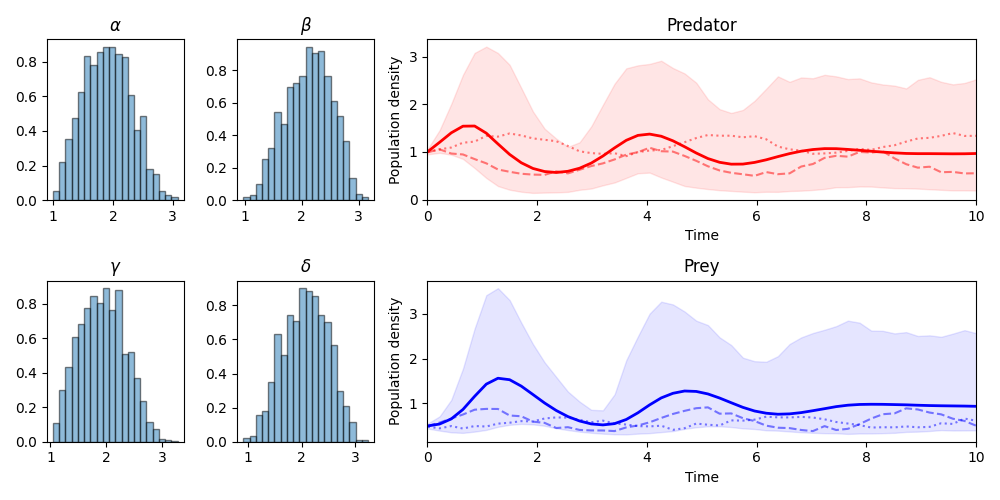

In [ ]:
%matplotlib widget

condition_mask = jnp.array([0]*T_max, dtype=int)
condition_value = jnp.array([0.]*T_max)

time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]
thetas = samples[:, :4]

fig = plt.figure(figsize=(10, 5))
grid = plt.GridSpec(2, 3, width_ratios=[1, 1, 4])

mean_predator = predator_trace.mean(axis=0)
min_predator = jnp.quantile(predator_trace, 0.025, axis=0)
max_predator = jnp.quantile(predator_trace, 0.975, axis=0)
mean_prey = prey_trace.mean(axis=0)
min_prey = jnp.quantile(prey_trace, 0.025, axis=0)
max_prey = jnp.quantile(prey_trace, 0.975, axis=0)

ax_right = plt.subplot(grid[0, 2])
ax_right2 = plt.subplot(grid[1, 2])
ax_upper_left = plt.subplot(grid[0, 0])
ax_lower_left = plt.subplot(grid[1, 0])
ax_upper_middle = plt.subplot(grid[0, 1])
ax_lower_middle = plt.subplot(grid[1, 1])

t1 =ax_upper_left.hist(thetas[:, 0], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_upper_left.set_title(r"$\alpha$")
t2 = ax_upper_middle.hist(thetas[:, 1], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_upper_middle.set_title(r"$\beta$")
t3 = ax_lower_left.hist(thetas[:, 2], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_lower_left.set_title(r"$\gamma$")
t4 = ax_lower_middle.hist(thetas[:, 3], bins=20, alpha=0.5, edgecolor='black', density=True)
ax_lower_middle.set_title(r"$\delta$")

m_pred = ax_right.plot(time_evals, mean_predator, c='red', lw=2)
m_prey = ax_right2.plot(time_evals, mean_prey, c='blue', lw=2)
q_pred = ax_right.fill_between(time_evals, min_predator, max_predator, alpha=0.1, color='red')
q_prey = ax_right2.fill_between(time_evals, min_prey, max_prey, alpha=0.1, color='blue')
linestyles = [':', '--']

t1_pred = ax_right.plot(time_evals, predator_trace[0], c='red', alpha=0.5, linestyle=linestyles[0])
t1_prey = ax_right2.plot(time_evals, prey_trace[0], c='blue', alpha=0.5, linestyle=linestyles[0])
t2_pred = ax_right.plot(time_evals, predator_trace[1], c='red', alpha=0.5, linestyle=linestyles[1])
t2_prey = ax_right2.plot(time_evals, prey_trace[1], c='blue', alpha=0.5, linestyle=linestyles[1])
    
ax_right.set_xlim(0, 10)
ax_right.set_title("Predator")
ax_right.set_xlabel("Time")
ax_right.set_ylabel("Population density")
ax_right2.set_xlim(0, 10)
ax_right2.set_title("Prey")
ax_right2.set_xlabel("Time")
ax_right2.set_ylabel("Population density")


l1 = None 
l2 = None
l3 = None
l4 = None

dots_prey = [None] * len(time_evals)
dots_predator = [None] * len(time_evals)

def onclick(event):
    global l1,l2,l3,l4
    global condition_mask, condition_value
    global time_evals
    global dots_predator, dots_prey
    global m_pred, m_prey, q_pred, q_prey, t1_pred, t1_prey, t2_pred, t2_prey
    global t1, t2, t3, t4
    global ax_right, ax_right2, ax_upper_left, ax_upper_middle, ax_lower_left, ax_lower_middle  
    ax = event.inaxes

    if ax is None:
        
        samples = jax.pmap(lambda k: sample_fn(k, (100, ), time_steps=200,node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
        samples = samples.reshape(-1, len(node_ids))
 
        m_pred[0].remove()
        m_prey[0].remove()
        q_pred.remove()
        q_prey.remove()
        t1_pred[0].remove()
        t1_prey[0].remove()
        t2_pred[0].remove()
        t2_prey[0].remove()
        try:
            t1[-1].remove()
        except:
            pass
        try:
            t2[-1].remove()
        except:
            pass
        try:
            t3[-1].remove()
        except:
            pass
        try:
            t4[-1].remove()
        except:
            pass
  
        time_evals = node_metadata[4:4 + num_timeponts]
        predator_trace = samples[:, 4:4 + num_timeponts]
        prey_trace = samples[:, 4+num_timeponts:]
        mean_predator = predator_trace.mean(axis=0)
        min_predator = jnp.quantile(predator_trace, 0.025, axis=0)
        max_predator = jnp.quantile(predator_trace, 0.975, axis=0)
        mean_prey = prey_trace.mean(axis=0)
        min_prey = jnp.quantile(prey_trace, 0.025, axis=0)
        max_prey = jnp.quantile(prey_trace, 0.975, axis=0)
        thetas = samples[:, :4]
        theta1 = thetas[:, 0]
        theta2 = thetas[:, 1]
        theta3 = thetas[:, 2]
        theta4 = thetas[:, 3]
        
        if l1 is None:
            t1 =ax_upper_left.hist(theta1,  alpha=0.5, edgecolor='black', density=True, color="C0")
        if l2 is None:
            t2 = ax_upper_middle.hist(theta2, alpha=0.5, edgecolor='black', density=True, color="C0")
        if l3 is None:
            t3 = ax_lower_left.hist(theta3, alpha=0.5, edgecolor='black', density=True, color="C0")
        if l4 is None:
            t4 = ax_lower_middle.hist(theta4, alpha=0.5, edgecolor='black', density=True, color="C0")
        

        m_pred =ax_right.plot(time_evals, mean_predator, c='red', lw=2)
        m_prey = ax_right2.plot(time_evals, mean_prey, c='blue', lw=2)
        q_pred =ax_right.fill_between(time_evals, min_predator, max_predator, alpha=0.1, color='red')
        q_prey=ax_right2.fill_between(time_evals, min_prey, max_prey, alpha=0.1, color='blue')
        linestyles = [':', '--']
   
        t1_pred =ax_right.plot(time_evals, predator_trace[0], c='red', alpha=0.5, linestyle=linestyles[0])
        t1_prey =ax_right2.plot(time_evals, prey_trace[0], c='blue', alpha=0.5, linestyle=linestyles[0])
        t2_pred =ax_right.plot(time_evals, predator_trace[1], c='red', alpha=0.5, linestyle=linestyles[1])
        t2_prey =ax_right2.plot(time_evals, prey_trace[1], c='blue', alpha=0.5, linestyle=linestyles[1])
        
        return
            
    else:
        x_data, y_data =  ax.transData.inverted().transform((event.x, event.y))
        
        if ax is ax_right:
            index = jnp.searchsorted(time_evals, jnp.array(x_data))
            t = float(time_evals[index])
            if dots_predator[index] is not None:
                dots_predator[index].remove()
                dots_predator[index] = None
                condition_mask = condition_mask.at[4 + index].set(0)
            else:
                dot = ax_right.scatter(t, y_data, c='red')
                dots_predator[index] = dot
                condition_value = condition_value.at[4 + index].set(y_data)
                condition_mask = condition_mask.at[4 +index].set(1)
        if ax is ax_right2:
            
            index = jnp.searchsorted(time_evals, jnp.array(x_data))
            t = float(time_evals[index])
            if dots_prey[index] is not None:
                dots_prey[index].remove()
                dots_prey[index] = None
                condition_mask = condition_mask.at[4  + num_timeponts + index].set(0)
            else:
                dot = ax_right2.scatter(t, y_data, c='blue')
                dots_prey[index] = dot
                condition_value = condition_value.at[4  +num_timeponts+ index].set(y_data)
                condition_mask = condition_mask.at[4  + num_timeponts+index].set(1)
        elif ax is ax_upper_left:
            if l1 is not None:
                l1.remove()
                l1 = None
                condition_mask = condition_mask.at[0].set(0)
                return
            l1 = ax_upper_left.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[0].set(1)
            condition_value = condition_value.at[0].set(x_data)
        elif ax is ax_upper_middle:
            if l2 is not None:
                l2.remove()
                l2 = None
                condition_mask = condition_mask.at[1].set(0)
                return
            l2 = ax_upper_middle.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[1].set(1)
            condition_value = condition_value.at[1].set(x_data)
        elif ax is ax_lower_left:
            if l3 is not None:
                l3.remove()
                l3 = None
                condition_mask = condition_mask.at[2].set(0)
                return
            l3 = ax_lower_left.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[2].set(1)
            condition_value = condition_value.at[2].set(x_data)
        elif ax is ax_lower_middle:
            if l4 is not None:
                l4.remove()
                l4 = None
                condition_mask = condition_mask.at[3].set(0)
                return
            l4 = ax_lower_middle.vlines(x_data, 0, 1, color='red', linestyle='--')
            condition_mask = condition_mask.at[3].set(1)
            condition_value = condition_value.at[3].set(x_data)
        
fig.tight_layout()

fig.canvas.mpl_connect('button_press_event', onclick)

In [ ]:
condition_mask = jnp.array([1,1,1,1] + [0]*(T_max-4), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + [0]*(T_max-4))


samples = sample_fn(jrandom.PRNGKey(0), (10, ), condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

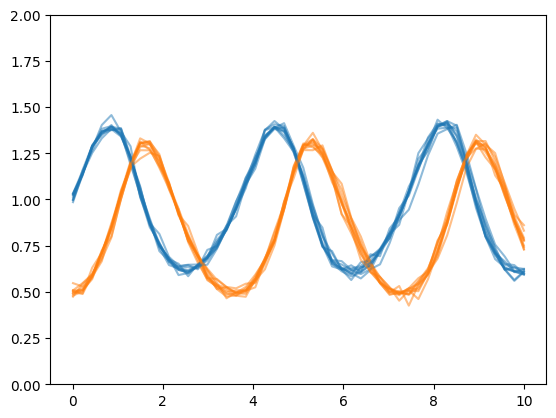

In [22]:
time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]

for i in range(10):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)
    plt.ylim(0,2)

In [ ]:
condition_mask = jnp.array([0,0,0,0] + [1]*(T_max-4), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + samples[0, 4:].tolist())

samples = sample_fn(jrandom.PRNGKey(0), (10, ), condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (500,) + inhomogeneous part.

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='theta1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='theta2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='theta3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='theta4'>]],
       dtype=object))

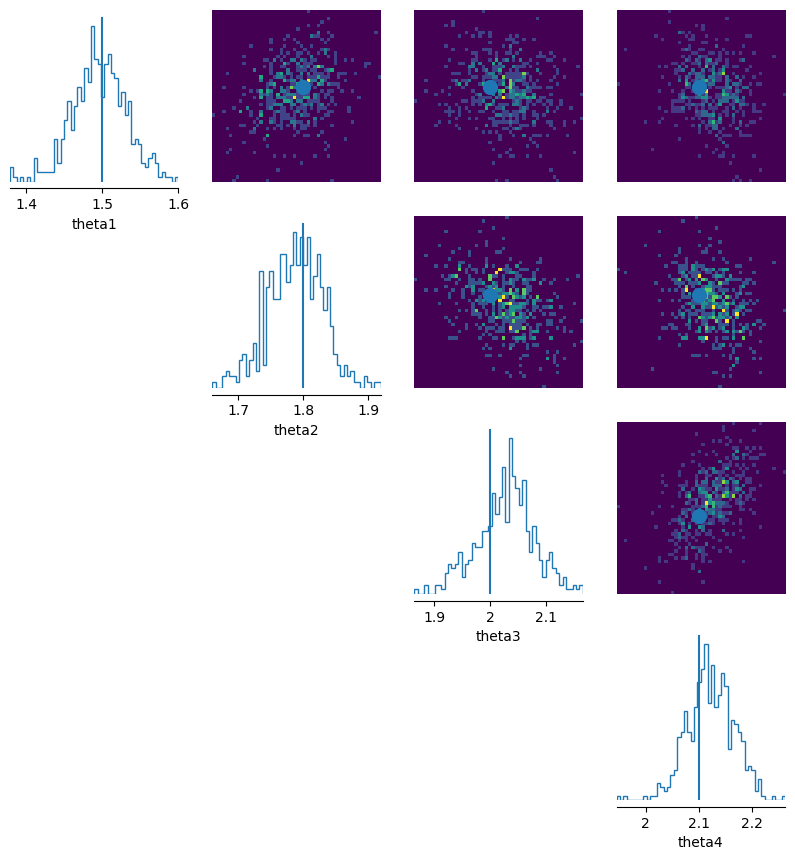

In [25]:
pairplot(np.array(samples[:, :4]), points=jnp.array([1.5, 1.8, 2., 2.1]), labels=["theta1", "theta2", "theta3", "theta4"])

In [29]:
condition_mask = jnp.array([0,0,0,0] + [0]*(T_max-4), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + [0]*(T_max-4))

condition_mask = condition_mask.at[20].set(1)
condition_value = condition_value.at[20].set(1.5)

condition_mask = condition_mask.at[15].set(1)
condition_value = condition_value.at[15].set(.5)

condition_mask = condition_mask.at[10].set(1)
condition_value = condition_value.at[10].set(1.)


samples = sample_fn(jrandom.PRNGKey(0), (100, ), condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

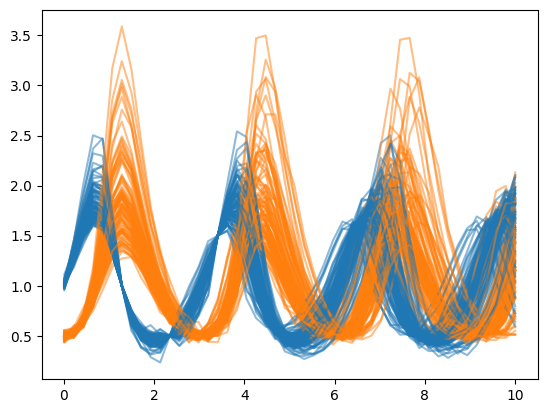

In [30]:
time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]

for i in range(100):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)


In [37]:
num_timeponts2 = 200
t1 = jnp.linspace(time_start + 0.01, time_end + 30, num_timeponts2)
node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts2 + [5] * num_timeponts2)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(t1) + list(t1)) # Time points

condition_mask = jnp.array([1,1,1,1] + [0]*(2*num_timeponts2), dtype=int)
condition_value = jnp.array([1.5, 1.8, 2., 2.1] + [0]*(2*num_timeponts2))


samples = sample_fn(jrandom.PRNGKey(1), (10, ), node_ids=node_ids, node_metadata=node_metadata, condition_mask=condition_mask, condition_value=condition_value, time_steps=2000)

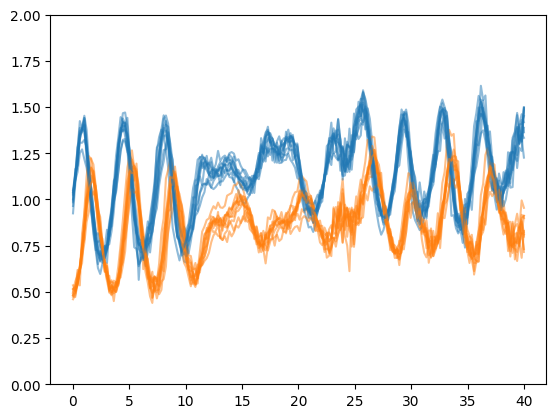

In [38]:
# Predicting the future

time_evals = node_metadata[4:4 + num_timeponts2]
predator_trace = samples[:, 4:4 + num_timeponts2]
prey_trace = samples[:, 4+num_timeponts2:]

for i in range(10):
    plt.plot(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.plot(time_evals, prey_trace[i], c='C1', alpha=0.5)
    plt.ylim(0,2)